In [1]:
import matplotlib.pyplot as plt
import numpy as np
from scipy.optimize import curve_fit

In [2]:
def adjust_exp_profile(x, y, start_index, end_index):
    # Fit an exponential curve to the selected data points
    log_y = np.log(y[start_index:end_index+1])
    coefficients = np.polyfit(x[start_index:end_index+1], log_y, deg=1)
    fitted_y = np.exp(np.polyval(coefficients, x))
    return fitted_y

In [3]:
# Read the data from the first text file
data1 = np.genfromtxt('Perfil_velocidades_Q10m3hora.txt', delimiter=',')
y1 = data1[:, 0]
x1 = data1[:, 1]
error1 = data1[:, 2]

In [4]:
# Read the data from the second text file
data2 = np.genfromtxt('Perfil_velocidades_Q15m3hora.txt', delimiter=',')
y2 = data2[:, 0]
x2 = data2[:, 1]
error2 = data2[:, 2]

In [5]:
# Read the data from the third text file
data3 = np.genfromtxt('Perfil_velocidades_Q30m3hora.txt', delimiter=',')
y3 = data3[:, 0]
x3 = data3[:, 1] #+ 3.5 # Shift x-coordinates by 3.5 units
x3_nodesplazado = data3[:, 1]
error3 = data3[:, 2]

In [6]:
# DELTA
# Select the specific points to mark in each dataset
index1 = 13  # Index of the point in dataset 1
index2 = 9  # Index of the point in dataset 2
index3 = 11  # Index of the point in dataset 3

# DELTA* EXP
# Select the specific points to mark in each dataset
index7 = 5  # Index of the point in dataset 1
index8 = 3  # Index of the point in dataset 2
index9 = 7  # Index of the point in dataset 3

#Ajuste log o exp:

start_index_log_1 = index7
start_index_log_2 = index8
start_index_log_3 = index9
end_index_log_1 = index1
end_index_log_2 = index2
end_index_log_3 = index3

# viscosidad cinematica
nu = 0.010034

Coeficiente V_f: 0.16457614387177233 +/- 0.01018281951664661
Coeficiente z_0: 0.016776408965838128 +/- 0.005915612464140961
m_1 = 0.275164111581968 +/- 0.11405220576287563


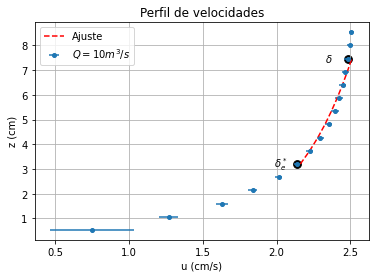

In [7]:
#Ajuste logarítmico caudal 10:

# Datos de muestra (x, y) y errores asociados a x
x = x1
y = y1
errors_x = error1

# Índices de inicio y fin del intervalo de datos
start_index = start_index_log_1
end_index = end_index_log_1

# Recortar los datos al intervalo especificado
x_interval = x[start_index:end_index+1]
y_interval = y[start_index:end_index+1]
errors_x_interval = errors_x[start_index:end_index+1]

# Definir la función a ajustar
def func(y, V_f, z_0):
    if np.any(y <= 0) or z_0 <= 0:
        return np.full_like(y, np.nan)
    else:
        return (2.5 * V_f) * np.log(y / z_0)
    
# Ajuste de curva utilizando mínimos cuadrados en el intervalo especificado
params, params_covariance = curve_fit(func, y_interval, x_interval, sigma=errors_x_interval)

# Obtener los coeficientes V_f y z_0
V_f = params[0]
z_0 = params[1]
m_1 = (V_f*z_0)/nu

# Obtener las incertidumbres asociadas a V_f y z_0 desde la matriz de covarianza
V_f_error = np.sqrt(params_covariance[0, 0])
z_0_error = np.sqrt(params_covariance[1, 1])
error_m1 = (abs(V_f*z_0_error)+abs(z_0*V_f_error))/nu

# Imprimir los resultados
print("Coeficiente V_f:", V_f, "+/-", V_f_error)
print("Coeficiente z_0:", z_0, "+/-", z_0_error)
print("m_1 =", m_1, "+/-", error_m1)

# Gráfico de los datos originales y la curva ajustada en el intervalo especificado

plt.errorbar(x, y, xerr=errors_x, fmt='o', label='$Q = 10 m^3/s$', markersize=4)
plt.plot(func(y_interval, V_f, z_0), y_interval, 'r-', label='Ajuste', linestyle='--')

# Plot the marked points with bigger black dots and captions(Deltas)
plt.scatter(x1[index1], y1[index1], s=60, c='black', marker='o')
plt.text(x1[index1] - 0.15 , y1[index1], f'$\delta$', ha='left', va='center')

# Plot the marked points with bigger black dots and captions(Deltas*experimentales)
plt.scatter(x1[index7], y1[index7], s=60, c='black', marker='o')
plt.text(x1[index7] - 0.15 , y1[index7], f'$\delta_e^*$', ha='left', va='center')

plt.xlabel('u (cm/s)')
plt.ylabel('z (cm)')
plt.title('Perfil de velocidades')
plt.grid()
plt.legend()
plt.savefig("Ajuste_Q=10.png",dpi=300, bbox_inches= "tight")
plt.show()


Coeficiente V_f: 0.1720642200008943 +/- 0.022379927298405194
Coeficiente z_0: 0.002104104885129019 +/- 0.0021185323539793964
m_2 = 0.036081439691030094 +/- 0.04102185881916783


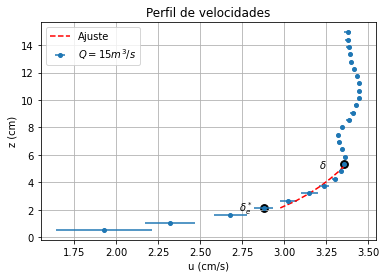

In [8]:
#Ajuste logarítmico caudal 15:

# Datos de muestra (x, y) y errores asociados a x
x = x2
y = y2
errors_x = error2

# Índices de inicio y fin del intervalo de datos
start_index = start_index_log_2
end_index = end_index_log_2

# Recortar los datos al intervalo especificado
x_interval = x[start_index:end_index+1]
y_interval = y[start_index:end_index+1]
errors_x_interval = errors_x[start_index:end_index+1]

# Definir la función a ajustar
def func(y, V_f, z_0):
    if np.any(y <= 0) or z_0 <= 0:
        return np.full_like(y, np.nan)
    else:
        return (2.5 * V_f) * np.log(y / z_0)
    
# Ajuste de curva utilizando mínimos cuadrados en el intervalo especificado
params, params_covariance = curve_fit(func, y_interval, x_interval, sigma=errors_x_interval, maxfev=2000)

# Obtener los coeficientes V_f y z_0
V_f = params[0]
z_0 = params[1]
m_2 = (V_f*z_0)/nu

# Obtener las incertidumbres asociadas a V_f y z_0 desde la matriz de covarianza
V_f_error = np.sqrt(params_covariance[0, 0])
z_0_error = np.sqrt(params_covariance[1, 1])
error_m2 = (abs(V_f*z_0_error)+abs(z_0*V_f_error))/nu

# Imprimir los resultados
print("Coeficiente V_f:", V_f, "+/-", V_f_error)
print("Coeficiente z_0:", z_0, "+/-", z_0_error)
print("m_2 =", m_2, "+/-", error_m2)

# Gráfico de los datos originales y la curva ajustada en el intervalo especificado
plt.errorbar(x, y, xerr=errors_x, fmt='o', label='$Q = 15 m^3 / s$', markersize=4)
plt.plot(func(y_interval, V_f, z_0), y_interval, 'r-', label='Ajuste', linestyle='--')

# Plot the marked points with bigger black dots and captions(Deltas)
plt.scatter(x2[index2], y2[index2], s=60, c='black', marker='o')
plt.text(x2[index2] - 0.15 , y2[index2], f'$\delta$', ha='left', va='center')

# Plot the marked points with bigger black dots and captions(Deltas*experimentales)
plt.scatter(x2[index8], y2[index8], s=60, c='black', marker='o')
plt.text(x2[index8] - 0.15 , y2[index8], f'$\delta_e^*$', ha='left', va='center')

plt.xlabel('u (cm/s)')
plt.ylabel('z (cm)')
plt.title('Perfil de velocidades')
plt.grid()
plt.legend()
plt.savefig("Ajuste_Q=15.png",dpi=300, bbox_inches= "tight")
plt.show()


Coeficiente V_f: 0.17694405861391416 +/- 0.012568906417652051
Coeficiente z_0: 2.658715843827596e-07 +/- 3.1784033660149074e-07
m_3 = 4.688498825074471e-06 +/- 5.9379782950667905e-06


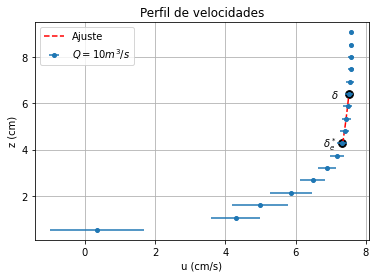

In [9]:
#Ajuste logarítmico caudal 30:

# Datos de muestra (x, y) y errores asociados a x
x = x3_nodesplazado
y = y3
errors_x = error3

# Índices de inicio y fin del intervalo de datos
start_index = start_index_log_3
end_index = end_index_log_3

# Recortar los datos al intervalo especificado
x_interval = x[start_index:end_index+1]
y_interval = y[start_index:end_index+1]
errors_x_interval = errors_x[start_index:end_index+1]

# Definir la función a ajustar
def func(y, V_f, z_0):
    if np.any(y <= 0) or z_0 <= 0:
        return np.full_like(y, np.nan)
    else:
        return (2.5 * V_f) * np.log(y / z_0)
    
# Ajuste de curva utilizando mínimos cuadrados en el intervalo especificado
params, params_covariance = curve_fit(func, y_interval, x_interval, sigma=errors_x_interval)

# Obtener los coeficientes V_f y z_0
V_f = params[0]
z_0 = params[1]
m_3 = (V_f*z_0)/nu

# Obtener las incertidumbres asociadas a V_f y z_0 desde la matriz de covarianza
V_f_error = np.sqrt(params_covariance[0, 0])
z_0_error = np.sqrt(params_covariance[1, 1])
error_m3 = (abs(V_f*z_0_error)+abs(z_0*V_f_error))/nu

# Imprimir los resultados
print("Coeficiente V_f:", V_f, "+/-", V_f_error)
print("Coeficiente z_0:", z_0, "+/-", z_0_error)
print("m_3 =", m_3, "+/-", error_m3)

# Gráfico de los datos originales y la curva ajustada en el intervalo especificado
plt.errorbar(x, y, xerr=errors_x, fmt='o', label='$Q = 10 m^3/s$', markersize=4)
plt.plot(func(y_interval, V_f, z_0), y_interval, 'r-', label='Ajuste', linestyle='--')

# Plot the marked points with bigger black dots and captions(Deltas)
plt.scatter(x3[index3], y3[index3], s=60, c='black', marker='o')
plt.text(x3[index3] - 0.5 , y3[index3], f'$\delta$', ha='left', va='center')

# Plot the marked points with bigger black dots and captions(Deltas*experimentales)
plt.scatter(x3[index9], y3[index9], s=60, c='black', marker='o')
plt.text(x3[index9] - 0.55 , y3[index9], f'$\delta_e^*$', ha='left', va='center')

plt.xlabel('u (cm/s)')
plt.ylabel('z (cm)')
plt.title('Perfil de velocidades')
plt.grid()
plt.legend()
plt.savefig("Ajuste_Q=30.png",dpi=300, bbox_inches= "tight")
plt.show()


In [16]:
#Delta teorica:
#Para v_0 he cogido la velocidad de los últimos puntos.
v0_1 = data1[15,1]
v0_2 = data2[18,1]
v0_3 = data3[16,1]
v1_1 = 0.99*v0_1
v1_2 = 0.99*v0_2
v1_3 = 0.99*v0_3
delta_teo1 = data1[index1,0]
delta_teo2 = data2[index2,0]
delta_teo3 = data3[index3,0]

error_v1_1 = 0.99*data1[15,2]
error_v1_2 = 0.99*data2[18,2]
error_v1_3 = 0.99*data3[16,2]

print("v0_1 =", v0_1, "+/-", data1[15,2])
print("v0_2 =", v0_2, "+/-", data2[18,2])
print("v0_3 =", v0_3, "+/-", data3[16,2])
print("v1_1 =", v1_1, "+/-", error_v1_1)
print("v1_2 =", v1_2, "+/-", error_v1_2)
print("v1_3 =", v1_3, "+/-", error_v1_3)
print("delta teórica 1 = ", delta_teo1)
print("delta teórica 2 = ", delta_teo2)
print("delta teórica 3 = ", delta_teo3)

v0_1 = 2.5064 +/- 0.0187
v0_2 = 3.4474 +/- 0.0083
v0_3 = 7.5916 +/- 0.053
v1_1 = 2.481336 +/- 0.018513
v1_2 = 3.412926 +/- 0.008217
v1_3 = 7.515683999999999 +/- 0.052469999999999996
delta teórica 1 =  7.4667
delta teórica 2 =  5.3333
delta teórica 3 =  6.4


In [11]:
#Delta*teo:

def Area(x,y,N):
    
    area_acumulada = 0
    n = 0
    
    while n < (N):
        
        delta_x = x[n+1] - x[n]
        area_trap = (0.5*delta_x)*(y[n+1]+y[n])
        area_acumulada += area_trap
        n += 1 
    return abs(area_acumulada)

y_10 = (1/v1_1)*(v1_1 - x1)
y_15 = (1/v1_2)*(v1_2 - x2)
y_30 = (1/v1_3)*(v1_3 - x3_nodesplazado)

Delta_asterisco_teórico1 = Area(y1,y_10,index1)
Delta_asterisco_teórico2 = Area(y2,y_15,index2)
Delta_asterisco_teórico3 = Area(y3,y_30,index3)


print("Delta*teórico1 =", Delta_asterisco_teórico1)
print("Delta*teórico2 =", Delta_asterisco_teórico2)
print("Delta*teórico3 =", Delta_asterisco_teórico3)

#Error Delta*teo:

error_f_1 = error1/v1_1
error_f_2 = error2/v1_2
error_f_3 = error3/v1_3

x1max = np.add(x1, error_f_1)
x2max = np.add(x2, error_f_2)
x3max = np.add(x3, error_f_3)

y_10 = (1/v1_1)*(v1_1 - x1max)
y_15 = (1/v1_2)*(v1_2 - x2max)
y_30 = (1/v1_3)*(v1_3 - x3max)

error_teórico1 = abs(Area(y1,y_10,index1)-Delta_asterisco_teórico1)
error_teórico2 = abs(Area(y2,y_15,index2)-Delta_asterisco_teórico2)
error_teórico3 = abs(Area(y3,y_30,index3)-Delta_asterisco_teórico3)

print("error_Delta*teórico1 =", error_teórico1)
print("error_Delta*teórico2 =", error_teórico2)
print("error_Delta*teórico3 =", error_teórico3)

Delta*teórico1 = 1.1070235378844304
Delta*teórico2 = 0.64580054328749
Delta*teórico3 = 0.9504229219589326
error_Delta*teórico1 = 0.04403597235746948
error_Delta*teórico2 = 0.027871510519125064
error_Delta*teórico3 = 0.03922069336647693


In [12]:
# DELTA*Teo
# Select the specific points to mark in each dataset
index10 = 1  # Index of the point in dataset 1
index11 = 1  # Index of the point in dataset 2
index12 = 1  # Index of the point in dataset 3

In [13]:
start_index1 = index7
end_index1 = index1

start_index2 = index8
end_index2 = index2

start_index3 = index9
end_index3 = index3

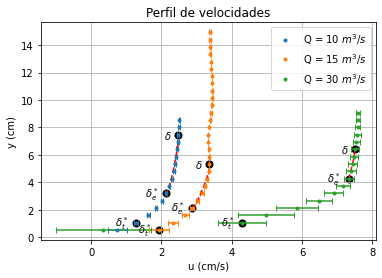

In [14]:
# Plot the first dataset
scatter1 = plt.errorbar(x1, y1, xerr=error1, fmt='o', label='Q = 10 m^3/s', markersize=3, capsize=3)

# Plot the second dataset
scatter2 = plt.errorbar(x2, y2, xerr=error2, fmt='o', label='Q = 15 m^3/s', markersize=3, capsize=3)

# Plot the third dataset
scatter3 = plt.errorbar(x3, y3, xerr=error3, fmt='o', label='Q = 30 m^3/s', markersize=3, capsize=3)


# Plot the marked points with bigger black dots and captions(Deltas)
plt.scatter(x1[index1], y1[index1], s=50, c='black', marker='o')
plt.text(x1[index1] - 0.4 , y1[index1], f'$\delta$', ha='left', va='center')

plt.scatter(x2[index2], y2[index2], s=50, c='black', marker='o')
plt.text(x2[index2] - 0.4 , y2[index2], f'$\delta$', ha='left', va='center')

plt.scatter(x3[index3], y3[index3], s=50, c='black', marker='o')
plt.text(x3[index3] - 0.4 , y3[index3], f'$\delta$', ha='left', va='center')



# Plot the marked points with bigger black dots and captions(Deltas*experimentales)
plt.scatter(x1[index7], y1[index7], s=50, c='black', marker='o')
plt.text(x1[index7] - 0.6 , y1[index7], f'$\delta_e^*$', ha='left', va='center')

plt.scatter(x2[index8], y2[index8], s=50, c='black', marker='o')
plt.text(x2[index8] - 0.6 , y2[index8], f'$\delta_e^*$', ha='left', va='center')

plt.scatter(x3[index9], y3[index9], s=50, c='black', marker='o')
plt.text(x3[index9] - 0.6 , y3[index9], f'$\delta_e^*$', ha='left', va='center')


# Plot the marked points with bigger black dots and captions(Deltas*teoricas)
plt.scatter(x1[index10], y1[index10], s=50, c='black', marker='o')
plt.text(x1[index10] - 0.6 , y1[index10], f'$\delta_t^*$', ha='left', va='center')

plt.scatter(x2[index11-1], y2[index11-1], s=50, c='black', marker='o')
plt.text(x2[index11-1] - 0.6 , y2[index11-1], f'$\delta_t^*$', ha='left', va='center')

plt.scatter(x3[index12], y3[index12], s=50, c='black', marker='o')
plt.text(x3[index12] - 0.6 , y3[index12], f'$\delta_t^*$', ha='left', va='center')

#Plot the marked points with bigger black dots and captions(Deltas*teoricas)
#plt.scatter(1, Delta_asterisco_teórico1, s=50, c='black', marker='o')
#plt.text(1 - 0.6 , Delta_asterisco_teórico1, f'$\delta_t^*$', ha='left', va='center')

#plt.scatter(2.5, Delta_asterisco_teórico2, s=50, c='black', marker='o')
#plt.text(2.5 - 0.6 , Delta_asterisco_teórico2, f'$\delta_t^*$', ha='left', va='center')

#plt.scatter(4.5, Delta_asterisco_teórico3, s=50, c='black', marker='o')
#plt.text(4.5 - 0.6 , Delta_asterisco_teórico3, f'$\delta_t^*$', ha='left', va='center')


# Adjust the data points to the exponential speed profile
fitted_y1 = adjust_exp_profile(x1, y1, start_index1, end_index1)
fitted_y2 = adjust_exp_profile(x2, y2, start_index2, end_index2)
fitted_y3 = adjust_exp_profile(x3, y3, start_index3, end_index3)

# Plot the adjusted curves within the desired range
plt.plot(x1[start_index1:end_index1+1], fitted_y1[start_index1:end_index1+1], color='red', linestyle='--',
         label='Exponential Fit')
plt.plot(x2[start_index2:end_index2+1], fitted_y2[start_index2:end_index2+1], color='red', linestyle='--')
plt.plot(x3[start_index3:end_index3+1], fitted_y3[start_index3:end_index3+1], color='red', linestyle='--')


# Set labels and title
plt.xlabel('u (cm/s)')
plt.ylabel('y (cm)')
plt.title('Perfil de velocidades')

# Add gridlines
plt.grid(True)

# Format the exponent in the legend
plt.legend(handles=[scatter1.lines[0], scatter2.lines[0], scatter3.lines[0]], labels=[r'Q = 10 $m^3/s$', r'Q = 15 $m^3/s$', r'Q = 30 $m^3/s$'])

#Guardar plot
plt.savefig("P5_plot.png",dpi=300, bbox_inches= "tight")

# Display the plot
plt.show()

# REVISAR LA DELTA QUE JA ESTÀ POSADA... NO ESTIC 100% SEGUR DE QUE SIGUI SA QUE TOCA PERQUE NO SÉ EXACTAMENT QUÈ CONSIDERAR COM V1 (COMPLETAMENT DESENVOLUPAT)
# FALTA AFEGIR DELTA* TEO I DELTA* EXP
# COMENTAR QUE SA TERCERA ESTÀ DESPLAÇADA 3.5 CM/S PERQUE SE VEGUI BÉ
# ANOMALIA EN EL COMPORTAMENT DE Q=15M^3/S... ES CORBA QUAN TOCARIA SER RECTE...